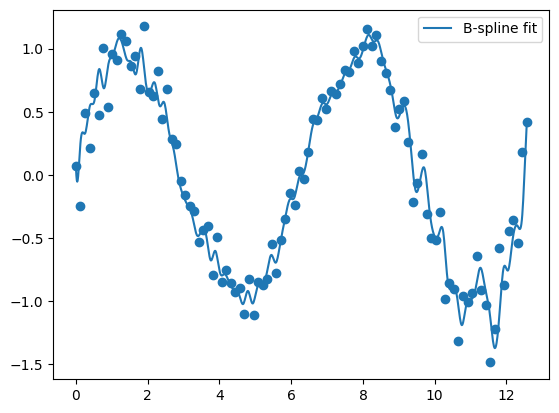

In [40]:
import numpy as np
from matplotlib import pyplot as plt


class BSpline:
    """
    Simple univariate B-spline basis evaluator.

    - Input `knots` are breakpoints, e.g. [0, 1, 2, 3, 4]
    - We build an open/clamped knot vector by repeating endpoints degree+1 times
    """

    def __init__(self, knots, degree):
        self.p = int(degree)

        # Breakpoints -> clamped knot vector
        k = np.asarray(knots, dtype=float)
        self.U = np.concatenate([
            np.full(self.p + 1, k[0]),   # left endpoint repeated
            k[1:-1],                     # interior knots once
            np.full(self.p + 1, k[-1])   # right endpoint repeated
        ])

        # Number of basis functions
        self.n_basis = len(self.U) - self.p - 1

        # Active parameter range
        self.u_min = self.U[self.p]
        self.u_max = self.U[-self.p - 1]

    def find_span(self, u):
        """Find k such that U[k] <= u < U[k+1], with right-endpoint handling."""
        n = self.n_basis - 1
        if u >= self.U[n + 1]:
            return n
        if u <= self.U[self.p]:
            return self.p
        return np.searchsorted(self.U, u, side="right") - 1

    def basis_at(self, u):
        """
        Evaluate all basis functions at one scalar u.
        Returns shape (n_basis,).
        """
        N = np.zeros(self.n_basis)

        # Outside domain => all zero
        if u < self.u_min or u > self.u_max:
            return N

        # Right endpoint convention: last basis = 1
        if u == self.u_max:
            N[-1] = 1.0
            return N

        k = self.find_span(u)
        p = self.p
        U = self.U

        # Local Cox-de Boor (only p+1 nonzero basis functions)
        local = np.zeros(p + 1)
        left = np.zeros(p + 1)
        right = np.zeros(p + 1)

        local[0] = 1.0
        for j in range(1, p + 1):
            left[j] = u - U[k + 1 - j]
            right[j] = U[k + j] - u
            saved = 0.0
            for r in range(j):
                denom = right[r + 1] + left[j - r]
                temp = 0.0 if denom == 0 else local[r] / denom
                local[r] = saved + right[r + 1] * temp
                saved = left[j - r] * temp
            local[j] = saved

        start = k - p
        N[start:k + 1] = local
        return N

    def basis_matrix(self, u_vals):
        """
        Evaluate all basis functions at many u values.
        Returns shape (len(u_vals), n_basis).
        """
        u_vals = np.asarray(u_vals, dtype=float)
        B = np.zeros((len(u_vals), self.n_basis))
        for i, u in enumerate(u_vals):
            B[i] = self.basis_at(float(u))
        return B

    def build_basis(self):
        """
        Return a list of basis callables N_i(u).
        Handy for plotting individual basis functions.
        """
        funcs = []
        for i in range(self.n_basis):
            funcs.append(lambda u, i=i: self.basis_at(float(u))[i])
        return funcs
    
    def set_control_points(self, control_points):
        """
        control_points: shape (n_ctrl, dim) or (n_ctrl,)

        If n_ctrl doesn't match current basis count, rebuild a simple clamped
        knot vector on the same [u_min, u_max] interval so dimensions align.
        """
        P = np.asarray(control_points, dtype=float)
        if P.ndim == 1:
            P = P[:, None]  # treat 1D output as one-channel curve

        n_ctrl = P.shape[0]
        if n_ctrl < self.p + 1:
            raise ValueError("need at least degree+1 control points")

        if n_ctrl != self.n_basis:
            # Build clamped knot vector with basis count == n_ctrl.
            u0, u1 = self.u_min, self.u_max
            interior_count = n_ctrl - self.p - 1
            interior = np.linspace(u0, u1, interior_count + 2)[1:-1]
            self.U = np.concatenate([
                np.full(self.p + 1, u0),
                interior,
                np.full(self.p + 1, u1),
            ])
            self.n_basis = len(self.U) - self.p - 1
            self.u_min = self.U[self.p]
            self.u_max = self.U[-self.p - 1]

        self.P = P

    def forward(self, u_vals):
        """Evaluate spline curve at one or many parameter values."""
        u_arr = np.atleast_1d(np.asarray(u_vals, dtype=float))
        B = self.basis_matrix(u_arr)  # (m, n_basis)
        C = B @ self.P                # (m, dim)

        # Return cleaner shapes for scalar/1D-output cases.
        if np.isscalar(u_vals):
            return C[0, 0] if C.shape[1] == 1 else C[0]
        return C[:, 0] if C.shape[1] == 1 else C

    def __call__(self, u_vals):
        """Make object callable: spline(u_vals)."""
        return self.forward(u_vals)
    
x = np.linspace(0, 4*np.pi, 100)
y = np.sin(x) + .2 * np.random.randn(100)



spline = BSpline(knots=x, degree=3)

# load the y values into the spline
spline.set_control_points(y)


u = np.linspace(0, 4*np.pi, 1000)
y_fit = spline(u)

plt.scatter(x, y)
plt.plot(u, y_fit, label='B-spline fit')
plt.legend()
plt.show()


In [41]:
import numpy as np
from dataclasses import dataclass


# -----------------------------
# Knot scheme helpers
# -----------------------------
def open_uniform_knots(n_ctrl, degree, u_min, u_max):
    """Open/clamped uniform knot vector for given control-point count."""
    interior_count = n_ctrl - degree - 1
    interior = np.linspace(u_min, u_max, interior_count + 2)[1:-1] if interior_count > 0 else np.array([])
    return np.concatenate([
        np.full(degree + 1, u_min),
        interior,
        np.full(degree + 1, u_max),
    ])


def open_quantile_knots(x, n_ctrl, degree):
    """Open/clamped knot vector with interior knots from x-quantiles."""
    x = np.asarray(x, dtype=float)
    u_min, u_max = x.min(), x.max()
    interior_count = n_ctrl - degree - 1
    if interior_count <= 0:
        interior = np.array([])
    else:
        q = np.linspace(0.0, 1.0, interior_count + 2)[1:-1]
        interior = np.quantile(x, q)
    return np.concatenate([
        np.full(degree + 1, u_min),
        interior,
        np.full(degree + 1, u_max),
    ])


# -----------------------------
# Basis-only class
# -----------------------------
class BSplineBasis:
    def __init__(self, knot_vector, degree):
        self.U = np.asarray(knot_vector, dtype=float)
        self.p = int(degree)
        self.n_basis = len(self.U) - self.p - 1
        self.u_min = self.U[self.p]
        self.u_max = self.U[-self.p - 1]

    def find_span(self, u):
        n = self.n_basis - 1
        if u <= self.U[self.p]:
            return self.p
        if u >= self.U[n + 1]:
            return n
        return int(np.searchsorted(self.U, u, side="right") - 1)

    def basis_at(self, u):
        N = np.zeros(self.n_basis)
        if u < self.u_min or u > self.u_max:
            return N
        if u == self.u_max:
            N[-1] = 1.0
            return N

        k = self.find_span(u)
        p = self.p
        U = self.U

        local = np.zeros(p + 1)
        left = np.zeros(p + 1)
        right = np.zeros(p + 1)
        local[0] = 1.0

        for j in range(1, p + 1):
            left[j] = u - U[k + 1 - j]
            right[j] = U[k + j] - u
            saved = 0.0
            for r in range(j):
                denom = right[r + 1] + left[j - r]
                temp = 0.0 if denom == 0 else local[r] / denom
                local[r] = saved + right[r + 1] * temp
                saved = left[j - r] * temp
            local[j] = saved

        N[k - p:k + 1] = local
        return N

    def basis_matrix(self, u_vals):
        u_vals = np.asarray(u_vals, dtype=float)
        B = np.zeros((len(u_vals), self.n_basis))
        for i, u in enumerate(u_vals):
            B[i] = self.basis_at(float(u))
        return B


# -----------------------------
# Technique 1: direct control points
# -----------------------------
class DirectControlSpline:
    def __init__(self, basis, control_points):
        self.basis = basis
        P = np.asarray(control_points, dtype=float)
        self.P = P[:, None] if P.ndim == 1 else P

    def __call__(self, u_vals):
        B = self.basis.basis_matrix(np.asarray(u_vals, dtype=float))
        C = B @ self.P
        return C[:, 0] if C.shape[1] == 1 else C


# -----------------------------
# Technique 2: least-squares fitted control points
# -----------------------------
@dataclass
class LeastSquaresSpline:
    basis: BSplineBasis
    P: np.ndarray

    @classmethod
    def fit(cls, x, y, basis, ridge=0.0):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        Y = y[:, None] if y.ndim == 1 else y

        B = basis.basis_matrix(x)  # (n_samples, n_basis)

        if ridge > 0:
            # Solve (B^T B + lambda I) P = B^T Y
            BTB = B.T @ B
            rhs = B.T @ Y
            P = np.linalg.solve(BTB + ridge * np.eye(BTB.shape[0]), rhs)
        else:
            # Ordinary least squares
            P, *_ = np.linalg.lstsq(B, Y, rcond=None)

        return cls(basis=basis, P=P)

    def __call__(self, u_vals):
        B = self.basis.basis_matrix(np.asarray(u_vals, dtype=float))
        C = B @ self.P
        return C[:, 0] if C.shape[1] == 1 else C

    def predict_on_x(self, x):
        return self(np.asarray(x, dtype=float))


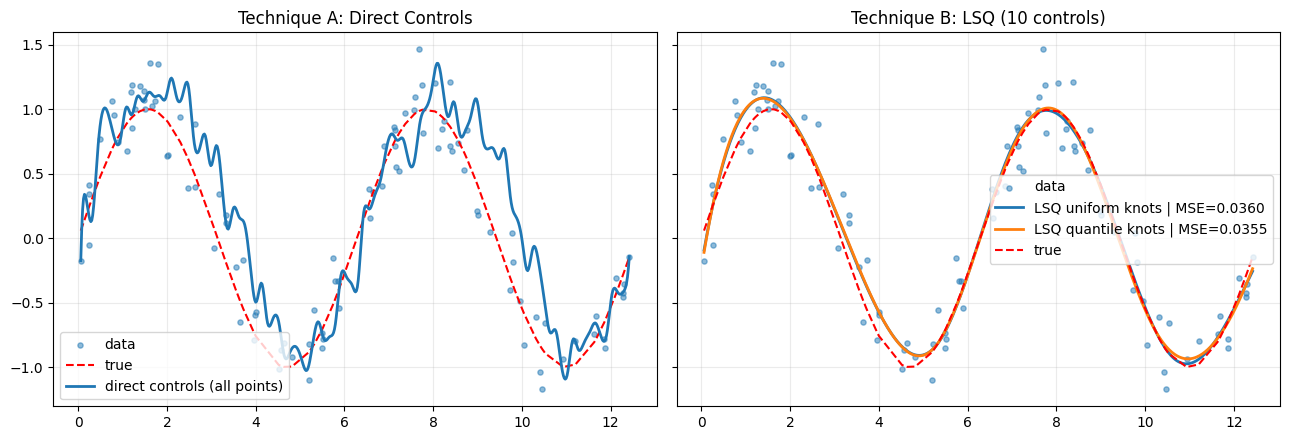

LSQ [uniform] -> train MSE: 0.035977
LSQ [quantile] -> train MSE: 0.035470


In [58]:
# -------------------------------------------
# Comparison experiment: techniques + knot schemes
# -------------------------------------------
np.random.seed(0)
x = np.random.uniform(0, 4 * np.pi, 100)
x = np.sort(x)
y = np.sin(x) + 0.2 * np.random.randn(len(x))

u = np.linspace(x.min(), x.max(), 600)
degree = 3

# Technique A: direct control points (uses all points)
direct_basis = BSplineBasis(
    open_uniform_knots(n_ctrl=len(x), degree=degree, u_min=x.min(), u_max=x.max()),
    degree=degree,
)
direct_model = DirectControlSpline(direct_basis, control_points=y)
y_direct = direct_model(u)

# Technique B: least squares with fewer control points
n_ctrl_small = 10
schemes = {
    "uniform": open_uniform_knots(n_ctrl_small, degree=degree, u_min=x.min(), u_max=x.max()),
    "quantile": open_quantile_knots(x, n_ctrl_small, degree=degree),
}

results = {}
for name, U in schemes.items():
    basis = BSplineBasis(U, degree=3)
    model = LeastSquaresSpline.fit(x, y, basis, ridge=1e-6)
    y_hat_u = model(u)
    y_hat_x = model.predict_on_x(x)
    mse = float(np.mean((y_hat_x - y) ** 2))
    results[name] = (model, y_hat_u, mse)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

ax[0].scatter(x, y, s=14, alpha=0.5, label="data")
ax[0].plot(x, np.sin(x), label="true", linestyle="--", color = "red")
ax[0].plot(u, y_direct, lw=2, label="direct controls (all points)")
ax[0].set_title("Technique A: Direct Controls")
ax[0].legend()
ax[0].grid(alpha=0.25)

ax[1].scatter(x, y, s=14, alpha=0.5, label="data")
for name, (_, y_hat_u, mse) in results.items():
    ax[1].plot(u, y_hat_u, lw=2, label=f"LSQ {name} knots | MSE={mse:.4f}")
ax[1].plot(x, np.sin(x), label="true", linestyle="--", color = "red")
ax[1].set_title(f"Technique B: LSQ ({n_ctrl_small} controls)")
ax[1].legend()
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Print quick metric table
for name, (_, _, mse) in results.items():
    print(f"LSQ [{name}] -> train MSE: {mse:.6f}")